# 1. Introduction

This notebook explores synthetic youth digital opportunity and employability data for a portfolio demonstration of impact analytics. The objective is to show how fragmented program data can be transformed into explainable insights that connect digital opportunity, learning engagement, skills readiness, and employment outcomes.

# 2. Environment Setup

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

from pathlib import Path

repo_root = Path.cwd()

if repo_root.name == "notebooks":
    repo_root = repo_root.parent

data_dir = repo_root / "data"
figures_dir = repo_root / "figures"

figures_dir.mkdir(exist_ok=True)

print("Repository:", repo_root)
print("Data:", data_dir)
print("Figures:", figures_dir)

print("Environment ready.")

Repository: c:\MYEO_Portfolio
Data: c:\MYEO_Portfolio\data
Figures: c:\MYEO_Portfolio\figures
Environment ready.


# 3. Data Loading

In [24]:
# Load the synthetic datasets

youth_df = pd.read_csv(data_dir / "youth.csv")
learning_df = pd.read_csv(data_dir / "learning_activity.csv")
skills_df = pd.read_csv(data_dir / "skills.csv")
employment_df = pd.read_csv(data_dir / "employment.csv")
opportunity_df = pd.read_csv(data_dir / "digital_opportunity_index.csv")
segments_df = pd.read_csv(data_dir / "youth_segments.csv")
risk_df = pd.read_csv(data_dir / "learning_engagement_risk.csv")

# Merge all datasets on youth_id
master_df = (
    youth_df.merge(learning_df, on="youth_id", how="left")
    .merge(skills_df, on="youth_id", how="left")
    .merge(employment_df, on="youth_id", how="left")
    .merge(opportunity_df, on="youth_id", how="left")
    .merge(segments_df, on="youth_id", how="left")
    .merge(risk_df, on="youth_id", how="left")
)

print(f"Master dataframe shape: {master_df.shape}")
print(f"Duplicate youth_id values: {master_df['youth_id'].duplicated().sum()}")
print("Missing values by column:")
print(master_df.isna().sum())

Master dataframe shape: (5000, 32)
Duplicate youth_id values: 0
Missing values by column:
youth_id                     0
age                          0
gender                       0
region                       0
urban_rural                  0
program_cohort               0
education_level              0
device_access                0
internet_access              0
digital_literacy             0
courses_enrolled             0
lessons_completed            0
learning_hours               0
login_frequency              0
last_activity_days           0
completion_rate              0
digital_skill_score          0
communication_score          0
problem_solving_score        0
english_score                0
career_readiness_score       0
job_search_status            0
internship_completed         0
job_placement                0
income_band                  0
digital_opportunity_score    0
opportunity_level            0
digital_readiness_score      0
learning_engagement_score    0
youth_segme

# 4. Exploratory Data Analysis

## Youth Demographics

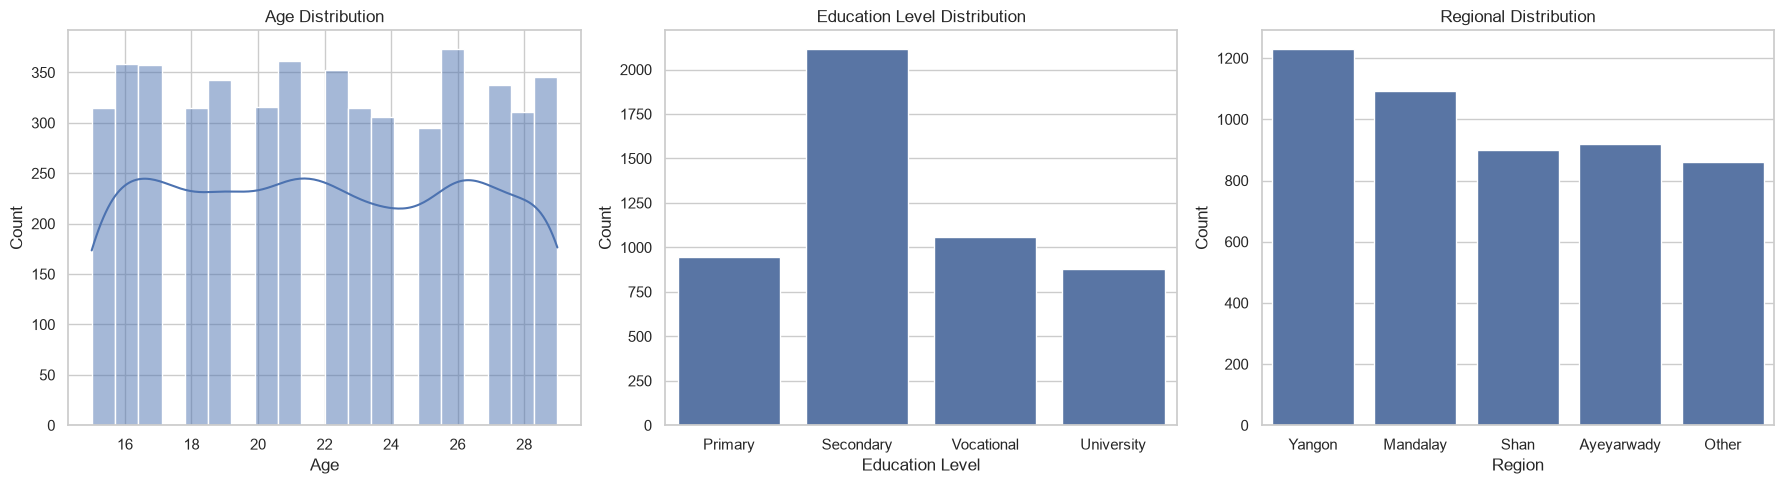

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(master_df["age"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

sns.countplot(data=master_df, x="education_level", order=["Primary", "Secondary", "Vocational", "University"], ax=axes[1])
axes[1].set_title("Education Level Distribution")
axes[1].set_xlabel("Education Level")
axes[1].set_ylabel("Count")

sns.countplot(data=master_df, x="region", order=["Yangon", "Mandalay", "Shan", "Ayeyarwady", "Other"], ax=axes[2])
axes[2].set_title("Regional Distribution")
axes[2].set_xlabel("Region")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig(figures_dir / "youth_demographics.png", dpi=300, bbox_inches="tight")
plt.show()

## Digital Opportunity Analysis

C:\Users\zlynn\AppData\Local\Temp\ipykernel_33912\1261795541.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=opportunity_counts.index, y=opportunity_counts.values, ax=axes[1], palette="viridis")


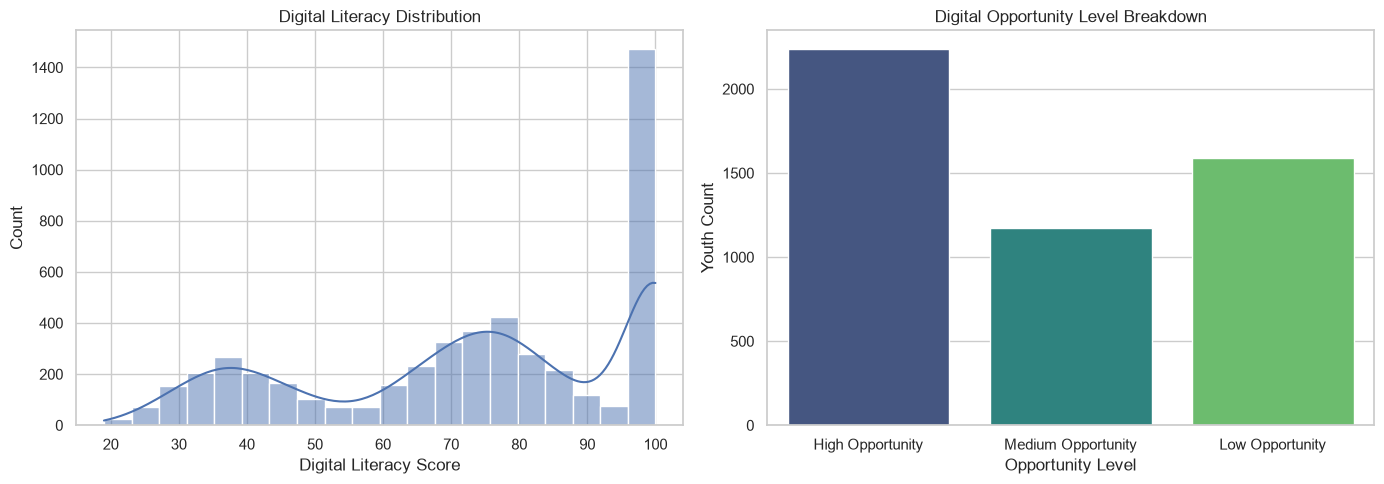

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(master_df["digital_literacy"], bins=20, kde=True, ax=axes[0])
axes[0].set_title("Digital Literacy Distribution")
axes[0].set_xlabel("Digital Literacy Score")
axes[0].set_ylabel("Count")

opportunity_counts = master_df["opportunity_level"].value_counts().reindex(["High Opportunity", "Medium Opportunity", "Low Opportunity"])
sns.barplot(x=opportunity_counts.index, y=opportunity_counts.values, ax=axes[1], palette="viridis")
axes[1].set_title("Digital Opportunity Level Breakdown")
axes[1].set_xlabel("Opportunity Level")
axes[1].set_ylabel("Youth Count")

plt.tight_layout()
plt.savefig(figures_dir / "digital_opportunity_gap.png", dpi=300, bbox_inches="tight")
plt.show()

## Youth Segmentation

C:\Users\zlynn\AppData\Local\Temp\ipykernel_33912\1753524307.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, palette=["#2ca25f", "#fdae6b", "#de2d26"])


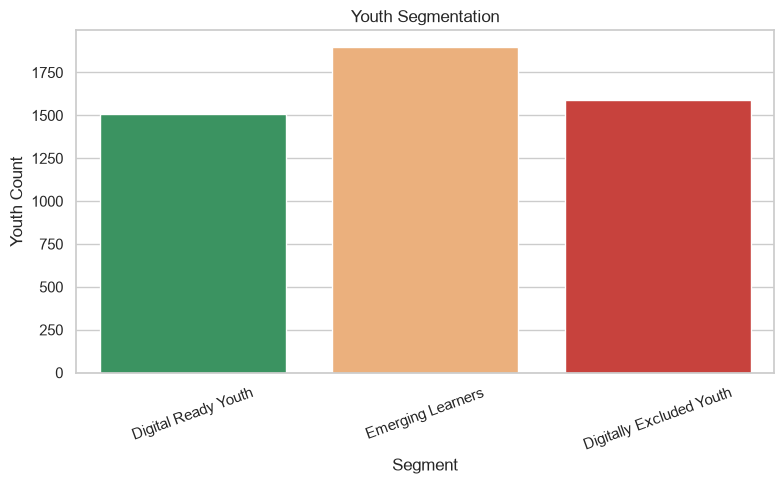

In [27]:
segment_counts = master_df["youth_segment"].value_counts().reindex(["Digital Ready Youth", "Emerging Learners", "Digitally Excluded Youth"])

plt.figure(figsize=(8, 5))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette=["#2ca25f", "#fdae6b", "#de2d26"])
plt.title("Youth Segmentation")
plt.xlabel("Segment")
plt.ylabel("Youth Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(figures_dir / "youth_segments.png", dpi=300, bbox_inches="tight")
plt.show()

## Learning Engagement Risk

This view highlights which learners may need additional support, re-engagement strategies, or tailored interventions.

C:\Users\zlynn\AppData\Local\Temp\ipykernel_33912\1588979593.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=risk_counts.index, y=risk_counts.values, palette=["#2ca25f", "#fdae6b", "#de2d26"])


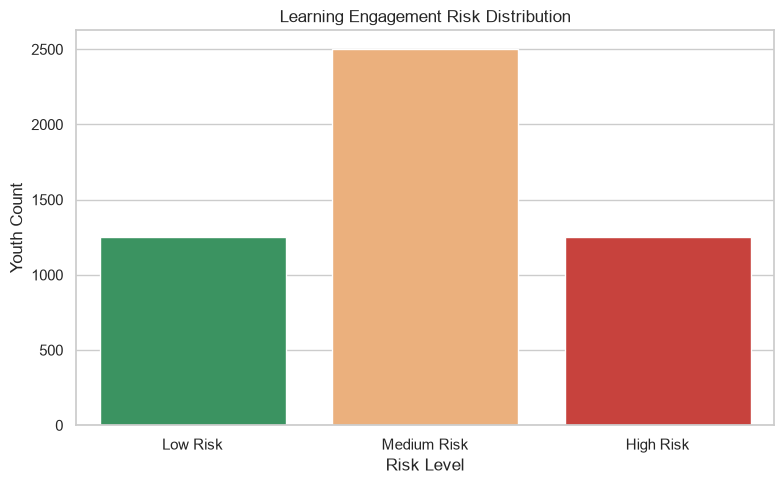

In [ ]:
risk_counts = master_df["risk_level"].value_counts().reindex(["Low Risk", "Medium Risk", "High Risk"])

plt.figure(figsize=(8, 5))
sns.barplot(x=risk_counts.index, y=risk_counts.values, palette=["#2ca25f", "#fdae6b", "#de2d26"])
plt.title("Learning Engagement Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Youth Count")
plt.tight_layout()
plt.savefig(figures_dir / "learning_risk.png", dpi=300, bbox_inches="tight")
plt.show()

## Skills and Employment Outcomes

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=master_df, x="job_placement", y="career_readiness_score", order=[0, 1])
plt.title("Career Readiness vs Job Placement")
plt.xlabel("Job Placement")
plt.ylabel("Career Readiness Score")
plt.tight_layout()
plt.savefig(figures_dir / "employability_outcomes.png", dpi=300, bbox_inches="tight")
plt.show()

# 5. Regional Digital Opportunity Gap

This chart compares regional differences in average digital opportunity and employment outcomes using simulated data.

In [ ]:
regional_summary = (
    master_df.groupby("region", as_index=False)
    .agg(
        youth_count=("youth_id", "count"),
        average_opportunity_score=("digital_opportunity_score", "mean"),
        employment_rate=("job_placement", "mean"),
        high_risk_percentage=("risk_level", lambda values: (values == "High Risk").mean() * 100),
    )
    .sort_values("average_opportunity_score", ascending=True)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    regional_summary["region"],
    regional_summary["average_opportunity_score"],
    color="#4C78A8",
)

ax.invert_yaxis()
ax.set_title("Regional Digital Opportunity Gap")
ax.set_xlabel("Average Digital Opportunity Score")
ax.set_ylabel("Region")
ax.set_xlim(0, 100)

for bar, score, employment in zip(
    bars,
    regional_summary["average_opportunity_score"],
    regional_summary["employment_rate"],
):
    ax.text(
        score + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.1f}\nEmp: {employment:.1%}",
        va="center",
        ha="left",
        fontsize=9,
        color="#2f2f2f",
    )

plt.tight_layout()
plt.savefig(figures_dir / "regional_digital_opportunity_gap.png", dpi=300, bbox_inches="tight")
plt.show()

Regions with lower digital opportunity may require targeted interventions to improve learning participation and employability outcomes. Digital access gaps can affect engagement and employment trajectories. This visualization is based on simulated data for a portfolio demonstration.

# 6. Save Report Figures

In [ ]:
print("Figures saved to:", figures_dir)

Figures saved to: c:\MYEO_Portfolio\figures


# 7. Key Insights

- Digital opportunity gaps are visible across regions and should be interpreted as part of a simulated portfolio demonstration of impact analytics.
- Youth segments with lower digital readiness and higher learning risk may benefit from targeted support and re-engagement strategies.
- Stronger career readiness is associated with better employability outcomes, supporting the logic of the impact pathway from opportunity to employability.

In [ ]:
master_df.groupby("youth_segment")[
    [
        "digital_literacy",
        "learning_hours",
        "completion_rate",
        "career_readiness_score",
        "job_placement"
    ]
].mean().round(2)

,digital_literacy,learning_hours,completion_rate,career_readiness_score,job_placement
youth_segment,,,,,
Digital Ready Youth,99.46,42.85,90.09,66.66,0.83
Digitally Excluded Youth,43.85,3.80,40.40,30.86,0.26
Emerging Learners,76.86,22.02,66.30,51.50,0.56
